# DATA 266 Lab 1 - Task 1: GPT-Style LLM From Scratch
**Name:** Viraat Chaudhary  
**Team:** 15  
**Runtime:** Google Colab GPU; verify the actual A100 below.

This notebook runs Viraat's separate implementation from source files. No assessed training or results are pre-populated. It retains configuration, raw logs, checkpoints, loss curves, all metrics and actual generations.

The proposed four-block post-norm/ReLU/untied decoder differs structurally from Anshika's five-block pre-norm/GELU/tied decoder. Review the configuration and be ready to justify your choices. Each member's training/evidence remains separate.

## Task 1 requirements from the assignment

**1.1 Data Preprocessing (5 Marks)**
1. Load the dataset and tokenize the text at the character level.
2. Create fixed-length input–target sequences suitable for autoregressive language modelling.
3. Convert characters into integer encodings using your own char_to_idx and idx_to_char dictionaries.
4. Split the dataset into training (100K) and validation (10K) sets — each member creates their own split.

**1.2 GPT Model Implementation (15 Marks)**
1. Implement one or more Transformer blocks from scratch, each consisting of: Multi-Head Self-Attention, Layer Normalization, Feed-Forward Network, and Residual connections.
2. Use causal masking in self-attention so the model cannot access future tokens during training.
3. Create learnable embedding layers for token embeddings and positional embeddings.
4. Add a language modelling head that projects the final hidden representations to the vocabulary size for next-token prediction.

**1.3 Training and Text Generation (8 Marks)**
1. Train the model using cross-entropy loss.
2. Implement learning rate warm-up and scheduling.
3. Train the model for a minimum of 10 epochs.
4. Plot and report training and validation loss curves.
5. Generate text samples using greedy decoding or temperature-based sampling.

**1.4 Sequence Model Failure Analysis (2 Marks)**
1. Analyse three failure cases observed in your generated text.
2. For each case, provide the generated text snippet and identify the type of failure (e.g., repetition, broken grammar, loss of coherence, hallucination) along with your observation.

**Report all metrics:** training/validation cross-entropy; perplexity; bits per character; generalization gap; top-1 next-character accuracy; Distinct-1/2/3; repeated 4-gram rate; gradient norms/stability; parameter count; training/generation tokens per second; peak memory; total training time.

**No prebuilt Transformer or attention modules.**

**Team 15's existing data convention:** the 100K/10K counts refer to fixed-length sequences, not stories. Both members assign disjoint story-record groups before creating sequences. This follows the partner's existing implementation; the brief itself does not explicitly name the counted unit.

## 1. Connect and verify the GPU
Select A100 in Runtime → Change runtime type, connect, then run this cell. The screenshot's selection is checked against the hardware actually assigned.

In [1]:
import sys, subprocess, json, os, tempfile, zipfile, hashlib
from pathlib import Path
import torch
assert torch.cuda.is_available(), "Connect the GPU runtime first."
gpu_name = torch.cuda.get_device_name(0)
print("Actual GPU:", gpu_name)
print("PyTorch:", torch.__version__, "CUDA:", torch.version.cuda)
assert "A100" in gpu_name, "The connected GPU is not the planned A100; reconnect/select the intended runtime."
subprocess.run(["nvidia-smi"], check=True)

Actual GPU: NVIDIA A100-SXM4-40GB
PyTorch: 2.11.0+cu128 CUDA: 12.8


CompletedProcess(args=['nvidia-smi'], returncode=0)

## 2. Persistent work folder and source upload
Mount your own Drive. This keeps weights and logs beyond runtime disconnections. Hugging Face caches remain in temporary local storage; they can be rebuilt from the frozen dataset revision.

On the first run, upload **Viraat_Task1_Source.zip** in the next cell. On a resume, the existing source is reused. Archive a different previous experiment before reusing this project folder.

In [3]:
from google.colab import drive, files
DRIVE_MOUNT = Path("/content/drive")
drive.mount(str(DRIVE_MOUNT), force_remount=True)
PROJECT_FOLDER = "DATA266_Lab1_Team15"
WORK_ROOT = DRIVE_MOUNT / "MyDrive" / PROJECT_FOLDER
WORK_ROOT.mkdir(parents=True, exist_ok=True)
MEMBER = WORK_ROOT / "task1_llm" / "Viraat_Chaudhary"
os.environ["TASK1_HF_CACHE"] = str(Path(tempfile.gettempdir()) / "data266_lab1_hf_cache")
if not (MEMBER / "code/train.py").exists():
    uploaded = files.upload()
    candidates = [name for name in uploaded if name.endswith(".zip")]
    assert len(candidates) == 1, "Upload only Viraat_Task1_Source.zip."
    with zipfile.ZipFile(candidates[0]) as archive:
        for item in archive.infolist():
            relative = Path(item.filename)
            assert not relative.is_absolute() and ".." not in relative.parts
            target = WORK_ROOT / relative
            if item.is_dir():
                target.mkdir(parents=True, exist_ok=True)
                continue
            payload = archive.read(item)
            if target.exists():
                assert hashlib.sha256(target.read_bytes()).digest() == hashlib.sha256(payload).digest(), "Existing source differs; archive the earlier experiment first."
            else:
                target.parent.mkdir(parents=True, exist_ok=True)
                target.write_bytes(payload)
print("Member source is available; checkpoints/logs will persist in this work folder.")

Mounted at /content/drive


Saving Viraat_Task1_Source.zip to Viraat_Task1_Source.zip
Member source is available; checkpoints/logs will persist in this work folder.


## 3. Install dependencies and inspect the frozen configuration
Keep Colab's CUDA-enabled PyTorch. The installation will retain it when it satisfies the version range. Do not reduce the 100,000/10,000 sequence counts or the minimum ten full epochs for the assessed run.

In [4]:
subprocess.run([sys.executable, "-m", "pip", "install", "-r", str(MEMBER / "requirements.txt")], check=True)
print((MEMBER / "configs/gpt_char.yaml").read_text())

def run_script(relative_script, *arguments):
    command = [sys.executable, str(WORK_ROOT / relative_script), *map(str, arguments)]
    process = subprocess.Popen(command, cwd=WORK_ROOT, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    for line in process.stdout:
        print(line, end="")
    if process.wait() != 0:
        raise RuntimeError("Command failed. Its untouched raw log remains in the member logs folder.")

experiment:
  name: viraat_postnorm_char_gpt_v1
  member_name: Viraat Chaudhary
  team_number: 15

data:
  dataset_id: roneneldan/TinyStories
  dataset_revision: f54c09fd23315a6f9c86f9dc80f725de7d8f9c64
  source_split: train
  text_field: text
  train_sequences: 100000
  validation_sequences: 10000
  sequence_length: 256
  split_seed: 2661502
  separator: "\n\n"

model:
  d_model: 256
  num_heads: 8
  num_layers: 4
  d_ff: 1024
  dropout: 0.15
  normalization: post_layer_norm
  activation: relu
  tie_token_and_output_embeddings: false
  positional_embeddings: learned
  layer_norm_epsilon: 1.0e-5

training:
  epochs: 10
  batch_size: 64
  learning_rate: 3.0e-4
  minimum_learning_rate: 3.0e-5
  warmup_ratio: 0.10
  scheduler: cosine
  weight_decay: 0.10
  adam_beta1: 0.90
  adam_beta2: 0.95
  gradient_clip_norm: 1.0
  precision: auto
  require_cuda: true
  num_workers: 0
  training_seed: 20260930
  log_every_steps: 100

generation:
  seed: 20260925
  max_new_characters: 500
  temperature

## 4. Correctness and synthetic smoke checks
These check causal masking, future-token isolation, target shifting, gradients, reloads, diversity definitions, and synthetic training/resume/evaluation. They use temporary data and create no assessed results in your folder.

In [5]:
subprocess.run([sys.executable, "-m", "pytest", str(MEMBER / "code/tests"), "-q"], check=True, cwd=WORK_ROOT)
run_script("task1_llm/Viraat_Chaudhary/code/smoke_test.py")

{"event": "RUN_START", "stage": "smoke", "created_utc": "2026-09-30T19:14:43.663257+00:00"}
{"event": "PREPROCESSING_COMPLETE", "train_sequences": 16, "validation_sequences": 4, "vocabulary_size": 20, "train_stories": 1, "validation_stories": 1}
{"event": "TRAINING_CONFIGURATION", "smoke_test": true, "device": "cuda", "gpu": {"name": "NVIDIA A100-SXM4-40GB", "total_memory_mib": 40441.375}, "precision": "fp32", "epochs": 2, "start_epoch": 1, "train_sequences": 16, "validation_sequences": 4, "parameters": 5236, "updates_per_epoch": 4, "total_planned_updates": 8}
{"event": "STEP", "epoch": 1, "update": 1, "batch": 1, "loss": 3.00654935836792, "learning_rate": 0.0003, "gradient_norm_before_clipping": 1.215986728668213}
{"event": "STEP", "epoch": 1, "update": 4, "batch": 4, "loss": 2.9935364723205566, "learning_rate": 0.0001950403260841024, "gradient_norm_before_clipping": 1.2733100652694702}
{"event": "EPOCH_COMPLETE", "epoch": 1, "training_loss": 2.9919241070747375, "validation_loss": 2.9

## 5. Preprocess TinyStories
This downloads the pinned dataset revision, uses your own split seed, constructs training-only character mappings and saves exactly 100K/10K rows of 257 IDs. Inputs contain the first 256 IDs; targets are shifted by one character. The manifest includes split ranges, counts, OOV coverage and hashes.

In [6]:
run_script("task1_llm/Viraat_Chaudhary/code/data.py")
manifest = json.loads((MEMBER / "outputs/metrics/split_manifest.json").read_text())
print("Train shape:", manifest["train_shape"], "Validation shape:", manifest["validation_shape"])
print("Vocabulary:", manifest["vocabulary_size"], "Story-record overlap:", manifest["story_record_overlap"])
assert manifest["train_shape"] == [100000, 257]
assert manifest["validation_shape"] == [10000, 257]

{"event": "RUN_START", "stage": "preprocessing", "created_utc": "2026-09-30T19:16:40.687178+00:00"}

README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]
README.md: 100%|##########| 1.06k/1.06k [00:00<00:00, 3.30MB/s]


data/train-00000-of-00004-2d5a1467fff108(…): reconstructing file:   0%|          |  0.00B /  249MB            
data/train-00000-of-00004-2d5a1467fff108(…): downloading bytes:           |  0.00B            

data/train-00000-of-00004-2d5a1467fff108(…): reconstructing file:   0%|          |  472kB /  249MB            
data/train-00000-of-00004-2d5a1467fff108(…): downloading bytes: 1         | 3.95MB            
data/train-00000-of-00004-2d5a1467fff108(…): downloading bytes: 4         | 10.5MB,  379kB/s  
data/train-00000-of-00004-2d5a1467fff108(…): downloading bytes: 6         | 16.7MB, 1.00MB/s  
data/train-00000-of-00004-2d5a1467fff108(…): downloading bytes: #         | 26.7MB, 1.59MB/s  
data/train-00000-of-00004-2d5a1467fff108(…): downloading bytes: #6        | 40.6

## 6. Train all ten epochs
The trainer visits every training sequence once per epoch, uses cross-entropy, warm-up/cosine scheduling and records pre-clipping gradient norms. On an A100, automatic precision chooses bfloat16. Best and last checkpoints are saved after each completed epoch; raw logs are never rewritten.

After disconnecting, reconnect, rerun setup, then rerun this cell. It resumes from the last completed epoch. An unfinished partial epoch is repeated; its attempt remains in the raw log.

In [8]:
arguments = ["--resume"] if (MEMBER / "checkpoints/last_checkpoint.pt").exists() else []
run_script("task1_llm/Viraat_Chaudhary/code/train.py", *arguments)
training = json.loads((MEMBER / "outputs/metrics/training_summary.json").read_text())
assert training["completed"] and training["epochs_completed"] >= 10
assert training["training_tokens"] == 100000 * 256 * training["epochs_completed"]
print("Completed epochs:", training["epochs_completed"], "Processed target characters:", training["training_tokens"])

{"event": "RUN_START", "stage": "training_resume", "created_utc": "2026-09-30T19:35:18.410392+00:00"}
{"event": "ALREADY_COMPLETE", "completed_epochs": 10}
{"event": "RUN_END", "stage": "training_resume"}
Completed epochs: 10 Processed target characters: 256000000


In [9]:
original_logs = [
    path
    for path in sorted((MEMBER / "logs").glob("training_*.log"))
    if not path.name.startswith("training_resume_")
]

assert original_logs, "Original training log not found."

for path in original_logs:
    print(f"\nOriginal training output — saved log: {path.name}\n")
    print(path.read_text(encoding="utf-8"))


Original training output — saved log: training_20260930T192119034828Z.log

{"event": "RUN_START", "stage": "training", "created_utc": "2026-09-30T19:21:19.039305+00:00"}
{"event": "TRAINING_CONFIGURATION", "smoke_test": false, "device": "cuda", "gpu": {"name": "NVIDIA A100-SXM4-40GB", "total_memory_mib": 40441.375}, "precision": "bf16", "epochs": 10, "start_epoch": 1, "train_sequences": 100000, "validation_sequences": 10000, "parameters": 3273824, "updates_per_epoch": 1563, "total_planned_updates": 15630}
{"event": "STEP", "epoch": 1, "update": 1, "batch": 1, "loss": 4.642727375030518, "learning_rate": 1.9193857965451053e-07, "gradient_norm_before_clipping": 3.264669179916382}
{"event": "STEP", "epoch": 1, "update": 100, "batch": 100, "loss": 3.7021372318267822, "learning_rate": 1.9193857965451055e-05, "gradient_norm_before_clipping": 2.537919521331787}
{"event": "STEP", "epoch": 1, "update": 200, "batch": 200, "loss": 2.8452348709106445, "learning_rate": 3.838771593090211e-05, "gradi

## 7. Evaluate and generate
Reload the selected checkpoint, evaluate full training/validation sets in FP32, and generate 30 outputs: three greedy plus 27 sampled continuations with the same prompts, temperatures, counts, lengths and seed as Anshika's saved protocol. Prompts are excluded from diversity metrics.

In [10]:
evaluation_path = MEMBER / "outputs/metrics/evaluation_metrics.json"
if not evaluation_path.exists():
    run_script("task1_llm/Viraat_Chaudhary/code/evaluate_generate.py")
else:
    print("Retaining the existing frozen evaluation.")
run_script("task1_llm/Viraat_Chaudhary/code/report.py")
evaluation = json.loads(evaluation_path.read_text())
print(json.dumps({"checkpoint": evaluation["checkpoint"], "validation": evaluation["validation"], "diversity": evaluation["diversity"]}, indent=2))

{"event": "RUN_START", "stage": "evaluation_generation", "created_utc": "2026-09-30T19:47:36.670143+00:00"}
{"event": "GENERATED_SAMPLE", "sample_id": "sample_001", "temperature": null, "repeated_4gram_rate": 0.7484909456740443}
{"event": "GENERATED_SAMPLE", "sample_id": "sample_002", "temperature": 0.7, "repeated_4gram_rate": 0.3118712273641851}
{"event": "GENERATED_SAMPLE", "sample_id": "sample_003", "temperature": 0.7, "repeated_4gram_rate": 0.2595573440643863}
{"event": "GENERATED_SAMPLE", "sample_id": "sample_004", "temperature": 0.7, "repeated_4gram_rate": 0.2052313883299799}
{"event": "GENERATED_SAMPLE", "sample_id": "sample_005", "temperature": 1.0, "repeated_4gram_rate": 0.16700201207243462}
{"event": "GENERATED_SAMPLE", "sample_id": "sample_006", "temperature": 1.0, "repeated_4gram_rate": 0.14688128772635814}
{"event": "GENERATED_SAMPLE", "sample_id": "sample_007", "temperature": 1.0, "repeated_4gram_rate": 0.17303822937625754}
{"event": "GENERATED_SAMPLE", "sample_id": "samp

## 8. Inspect metric evidence and loss curves
The primary generalization gap uses training/validation inference loss at the same checkpoint with dropout disabled. The original partner's epoch-average training definition is retained separately for the legacy comparison. Character-level Distinct-1 is naturally small; inspect samples alongside numeric diversity.

training_cross_entropy_loss: 0.8575841665267945
final_epoch_training_cross_entropy_loss: 0.9326997169876099
validation_cross_entropy_loss: 0.8637021662712098
perplexity: 2.3719257223049572
bits_per_character: 1.2460588320845294
generalization_gap: 0.006117999744415292
top1_next_character_accuracy: 0.727812109375
distinct_1: 0.0045925925925925926
distinct_2: 0.04215839085578565
distinct_3: 0.16659229510635132
repeated_4gram_rate: 0.17467769580445636
gradient_norm_mean: 0.6247545246332789
gradient_norm_max: 3.3099968433380127
loss_spike_count: 0
nonfinite_loss_count: 0
nonfinite_gradient_count: 0
parameter_count: 3273824
training_tokens_per_second: 590870.7275939166
total_training_seconds: 451.62236405800104
peak_gpu_allocated_mb: 1758.94873046875
peak_gpu_reserved_mb: 2034.0
peak_cpu_rss_mb: 1674.8984375
generation_tokens_per_second: 696.0130767304037


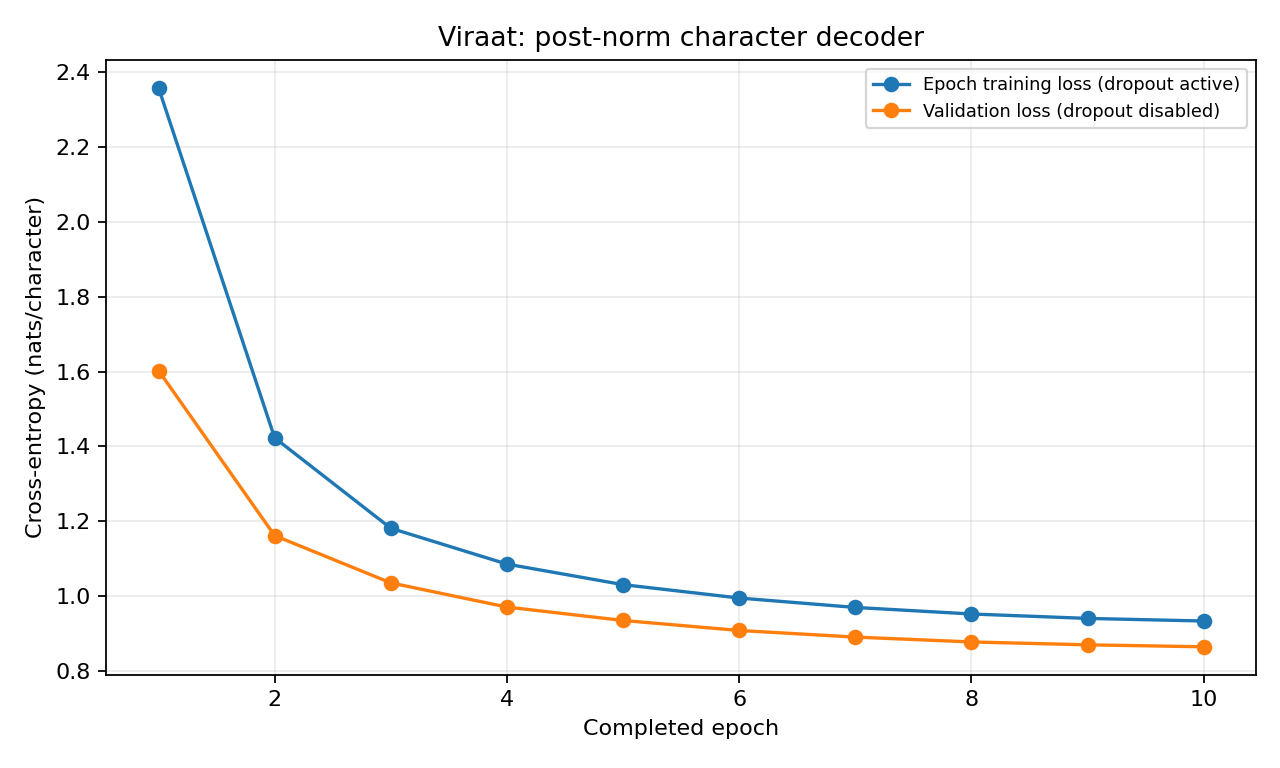

# Task 1 Results - Viraat Chaudhary

Status: Full training and evaluation complete; manual failure/design interpretation is still pending.

## Data and architecture

Dataset: `roneneldan/TinyStories`; revision: `f54c09fd23315a6f9c86f9dc80f725de7d8f9c64`; split seed: 2661502.

The existing Team 15 protocol counts fixed-length sequences: 100,000 training / 10,000 validation, context 256. Story-record groups are disjoint before sequence construction; only training text builds the vocabulary.

4 post-norm blocks; width 256; heads 8; feed-forward width 1024; ReLU; dropout 0.15; learned positions; untied output head. Attention, causal masking and layer normalization use explicit tensor operations.

This differs from Anshika's pre-norm/GELU/tied-output decoder. The comparison changes several factors and is not a controlled one-factor ablation.

## Training

Completed epochs: 10; batch size: 64; optimizer: AdamW; peak LR: 0.0003; minimum LR: 3e-05; warm-up: 10%; cosine decay; precision: bf16; best checkpoint epoch: 10.

## Required metrics

| Metric | Value |

|---|---:|

| training_cross_entropy_loss | 0.85758417 |

| final_epoch_training_cross_entropy_loss | 0.93269972 |

| validation_cross_entropy_loss | 0.86370217 |

| perplexity | 2.3719257 |

| bits_per_character | 1.2460588 |

| generalization_gap | 0.0061179997 |

| top1_next_character_accuracy | 0.72781211 |

| distinct_1 | 0.0045925926 |

| distinct_2 | 0.042158391 |

| distinct_3 | 0.1665923 |

| repeated_4gram_rate | 0.1746777 |

| gradient_norm_mean | 0.62475452 |

| gradient_norm_max | 3.3099968 |

| loss_spike_count | 0 |

| nonfinite_loss_count | 0 |

| nonfinite_gradient_count | 0 |

| parameter_count | 3273824 |

| training_tokens_per_second | 590870.73 |

| total_training_seconds | 451.62236 |

| peak_gpu_allocated_mb | 1758.9487 |

| peak_gpu_reserved_mb | 2034 |

| peak_cpu_rss_mb | 1674.8984 |

| generation_tokens_per_second | 696.01308 |



## Metric definitions and evidence

Primary training/validation cross-entropy and generalization gap use FP32 inference with dropout disabled on both full sets at the same selected checkpoint. The final-epoch online training loss is reported separately. Anshika's saved training loss/gap instead use epoch-average training loss, so these two definitions must not be silently mixed.

Perplexity = exp(validation CE); bits per character = validation CE / ln(2); generalization gap = validation CE minus training CE. Accuracy counts correct next-character predictions across all validation target positions.

Distinct-n is unique character n-grams divided by their total occurrences over the 27 sampled continuations. Prompts and cross-sample boundaries are excluded. Repeated 4-gram rate is the mean per-continuation duplicate-occurrence fraction. Greedy samples are preserved but excluded from sampled diversity totals.

Gradient norms are measured before clipping. A loss spike exceeds 1.5 times the median of the previous 20 minibatch losses. Nonfinite losses/gradients stop the run and are recorded in untouched logs. Training throughput uses processed target characters divided by completed training-pass time; generation throughput includes both greedy and sampled generated characters.

Sum of completed epoch training, validation, best-checkpoint and plot/metric writes; excludes preprocessing, setup, last-checkpoint write and uncheckpointed interrupted work

Evidence: metrics_report.csv; outputs/metrics/evaluation_metrics.json; training_summary.json; training_history.csv; step_metrics.csv; split_manifest.json; outputs/plots/loss_curves.png; outputs/samples/generated_samples.json; logs/; checkpoints/; environment_manifest.txt.

## Interpretation to review and defend

Explain why you selected the post-norm/ReLU/untied architecture and these hyperparameters. Inspect the curves and generated samples before writing conclusions about generalization, diversity, grammar or coherence. State the own-split and hardware limitations when comparing the models. The implementation does not infer qualitative failure observations from numeric metrics.

## References

Vaswani et al. (2017), Attention Is All You Need: https://arxiv.org/abs/1706.03762

Eldan and Li (2023), TinyStories: https://arxiv.org/abs/2305.07759


In [11]:
import csv
from IPython.display import display, Image, Markdown
for row in csv.DictReader((MEMBER / "metrics_report.csv").open()):
    print(f"{row['metric']}: {row['value']}")
display(Image(filename=str(MEMBER / "outputs/plots/loss_curves.png")))
display(Markdown((MEMBER / "results.md").read_text()))

## 9. Manually review the actual generated failures
Choose three different sample IDs. Copy exact excerpts and write your observations/fixes based on the actual outputs. Do not invent, repair or substitute generated text.

In [12]:
samples = json.loads((MEMBER / "outputs/samples/generated_samples.json").read_text())["samples"]
for sample in samples:
    print(f"\n{sample['sample_id']} | {sample['mode']} | temperature={sample['temperature']} | repeated-4gram={sample['repeated_4gram_rate']:.4f}")
    print("Prompt:", sample["prompt"])
    print(sample["continuation"])


sample_001 | greedy | temperature=None | repeated-4gram=0.7485
Prompt: Once upon a time
, there was a little girl named Lily. She loved to play with her toys and said, "Thank you, Lily. You are very sad. You are a good friend. You are very sad. You are a good friend. You are very sad. You are a good friend. You are very sad. You are a good friend. You are very sad. You are very sad. You are very sad. You are very sad. You are very sad. You are very sad. You are very sad. You are very sad. You are very sad. You are very sad. You are very sad. You are very sad. You are very sad. You 

sample_002 | sampled | temperature=0.7 | repeated-4gram=0.3119
Prompt: Once upon a time
, there was a little girl named Lily. She loved to play with her mom, who was very sad and they started to everyone her very happy. She was so happy and loved boat to play with her friends. One day, she saw a young bird and saw a big box and decided to always always saw the stars. She was so happy that her mom and dad s

In [13]:
from google.colab import files

files.download(str(MEMBER / "metrics_report.csv"))
files.download(
    str(MEMBER / "outputs/samples/generated_samples.json")
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Your failure analysis and design/results interpretation
Fill the two inputs below after inspecting your results. Each failure case needs `sample_id`, `excerpt`, `failure_type`, `observation` and `testable_fix`. Your design/hyperparameter choices and analysis must be understood and defensible in the viva.

Suggested interpretation prompts: Why post-norm/ReLU/untied weights? What do warm-up, batch size, context length and dropout control? What do your curves and samples actually show? What remains uncertain, and what experiment would you try next?

In [14]:
import csv
import hashlib
import json
import math
from pathlib import Path
from IPython.display import Markdown, display

FAILURE_CASES = [
    {
        "sample_id": "sample_001",
        "excerpt": "You are very sad. You are a good friend. You are very sad. You are a good friend. You are very sad. You are a good friend.",
        "failure_type": "Repetitive generation loop",
        "observation": "The same sentence pair appears three consecutive times in this excerpt, and the full continuation later repeats 'You are very sad.' many more times without developing the story. This greedy sample has a character-level repeated 4-gram rate of 0.748491. That is its individual rate; the reported aggregate rate of 0.174678 covers only the 27 sampled continuations and excludes greedy outputs.",
        "testable_fix": "As a decoding experiment, keep this checkpoint, the three prompts and the 500-character generation budget fixed. Compare greedy decoding with sampling at temperature 0.7 over several recorded seeds. Measure consecutive repeated-sentence runs and the character-level repeated 4-gram rate, and inspect grammar as well. Sampling may break the loop, but an improvement should be measured rather than assumed."
    },
    {
        "sample_id": "sample_006",
        "excerpt": ", there was a little girl called Jelie, \"Zoomp! I love you. Thank you, Grandma!\" Lily said.",
        "failure_type": "Unexplained speaker or character-name change",
        "observation": "The continuation introduces a girl called Jelie, but immediately attributes the quoted speech to Lily without introducing Lily or explaining the relationship. This leaves the speaker's identity ambiguous. The excerpt does not establish whether Lily is another character or an unintended replacement name. The example was sampled at temperature 1.0.",
        "testable_fix": "In a future training experiment, test whether additional training at a small learning rate improves character-name consistency while keeping the architecture and split fixed. Compare the resulting checkpoint with this frozen checkpoint on the same reserved prompts, generation length, temperature 1.0 and recorded sampling seeds. Count unexplained name changes and inspect validation loss. This is a proposed experiment, not a demonstrated fix."
    },
    {
        "sample_id": "sample_018",
        "excerpt": "Lily noticed down the tib legs. She splashed the stame. She's notice and kicked some chone flowersh.",
        "failure_type": "Malformed words and grammar",
        "observation": "The excerpt contains nonstandard word forms such as 'stame', 'chone' and 'flowersh', and 'She's notice' is grammatically malformed in this context. These errors make the events difficult to interpret even though the continuation contains familiar story words and a character name. This sample used temperature 1.3; one example cannot establish temperature as the only cause.",
        "testable_fix": "For a controlled decoding experiment, keep the checkpoint, prompts and 500-character generation budget fixed and compare temperatures 0.7, 1.0 and 1.3 over matched recorded seeds. Manually count malformed words and grammatical errors alongside repeated 4-gram rates. Test whether a lower temperature improves readability, and check whether that improvement comes with more repetition."
    }
]

INTERPRETATION = {
    "architecture_justification": "The implemented configuration is a small causal character decoder with four post-norm blocks, width 256, eight attention heads and feed-forward width 1024. Each head uses 32 features, and the feed-forward layer expands the width by a factor of four before projecting it back. Explicit causal masking restricts each position to its own and earlier characters; residual connections preserve a path around each attention and feed-forward sublayer. Post-norm applies layer normalization after each residual addition. ReLU supplies the feed-forward nonlinearity. Learned token and position embeddings represent character identity and position. The untied output head has its own weights instead of sharing the input embedding weights, allowing the two mappings to be learned separately. For this run, the training vocabulary has 96 entries and the model has 3,273,824 parameters. These are technically reasonable design choices for a small scratch implementation, but this run does not demonstrate that they outperform pre-norm, GELU or tied weights.",
    "hyperparameter_justification": "The context length is 256 characters, following the existing team sequence protocol. Batch size 64 and BF16 execution use the observed A100 GPU while keeping the assessed training at ten full epochs. AdamW uses a peak learning rate of 0.0003, weight decay 0.1 and beta values 0.9 and 0.95. A 10% linear warm-up reaches the peak learning rate gradually, followed by cosine decay to 0.00003. With 1,563 updates per epoch and 15,630 total planned updates, warm-up lasts 1,563 updates. Dropout 0.15 and weight decay provide regularization, and gradient clipping at norm 1.0 limits unusually large gradient updates. Gradient norms in the report are measured before clipping, so a recorded maximum above 1.0 is consistent with that configuration. Ten epochs process 256,000,000 target characters. These settings define this experiment; no hyperparameter search or claim of optimal settings is supported by the saved run.",
    "observations": "Both epoch training and validation losses decrease throughout the ten-epoch run. Epoch training loss decreases from 2.359281 to 0.932700, and epoch validation loss decreases from 1.602774 to 0.863752. Epoch 10 is the selected checkpoint. At that checkpoint, FP32 evaluation with dropout disabled gives training CE 0.857584 and validation CE 0.863702, hence a generalization gap of 0.006118 nats per character. Validation perplexity is 2.371926, BPC is 1.246059 and next-character accuracy is 72.7812%. The plotted training loss averages predictions made during learning with dropout active; it should not be substituted for the final checkpoint's inference training loss. The curves show no rising-validation-loss trend within these ten epochs, but the small inference gap alone does not establish strong generalization or good story quality. The metrics record zero detected loss spikes, nonfinite losses and nonfinite gradients. Thirty 500-character continuations were saved. Greedy outputs contain strong repetition, while sampled outputs also exhibit ambiguous character identities, grammatical errors and malformed words. Across the 27 sampled continuations only, character-level Distinct-1/2/3 are 0.004593, 0.042158 and 0.166592, and the mean repeated 4-gram rate is 0.174678. These diversity statistics do not measure narrative coherence.",
    "limitations_and_next_steps": "The counts follow the repository's fixed-sequence convention: 100,000 training sequences and 10,000 validation sequences, rather than those numbers of complete stories. Story-record groups are disjoint before window construction and the vocabulary is built only from training text. This is one architecture, split seed and training seed, with qualitative generation evaluated using three prompts; it is not a controlled ablation or a broad benchmark. A 256-character attention context limits the history available during 500-character generation, although it does not by itself explain every observed failure. Anshika's validation split and training-loss definition differ, and her training hardware also differs, so individual validation metrics and hardware throughput cannot isolate architecture effects. Both frozen models should be evaluated on the same reserved holdout with the same metric protocol before the team chooses the final model. Future work can compare one architecture choice at a time while holding other settings fixed, repeat training across seeds, and test the proposed decoding and name-consistency experiments. Those experiments have not been run, and their outcomes should not be stated as improvements."
}

# Check the actual Colab artifacts before writing the analysis inputs.
root = Path(MEMBER)
sample_path = root / "outputs/samples/generated_samples.json"
metric_path = root / "metrics_report.csv"
evaluation_path = root / "outputs/metrics/evaluation_metrics.json"
assert sample_path.is_file() and metric_path.is_file() and evaluation_path.is_file(), (
    "Complete Sections 7-9 before running Section 10."
)

sample_payload = json.loads(sample_path.read_text(encoding="utf-8"))
lookup = {sample["sample_id"]: sample for sample in sample_payload["samples"]}
evaluation = json.loads(evaluation_path.read_text(encoding="utf-8"))
with metric_path.open(encoding="utf-8", newline="") as handle:
    metric_rows = list(csv.DictReader(handle))
metrics = {row["metric"]: float(row["value"]) for row in metric_rows}

assert not evaluation["smoke_test"], "Synthetic smoke-test output cannot be used here."
assert evaluation["checkpoint"]["epoch"] == 10
assert evaluation["training"]["epochs_completed"] == 10
assert evaluation["training"]["completed"]
assert evaluation["model"]["parameter_count"] == 3273824
assert evaluation["model"]["vocabulary_size"] == 96
assert len(lookup) == 30 and all(
    len(sample["continuation_token_ids"]) == 500 for sample in lookup.values()
)
assert all(row["checkpoint_epoch"] == "10" for row in metric_rows)

for key, expected in {
    "training_cross_entropy_loss": 0.8575841665267945,
    "validation_cross_entropy_loss": 0.8637021662712098,
    "generalization_gap": 0.006117999744415292,
}.items():
    assert math.isclose(metrics[key], expected, rel_tol=1e-10, abs_tol=1e-10), (
        f"{key} differs from the reviewed run. Review this analysis before using it."
    )

assert len(FAILURE_CASES) == 3
assert len({case["sample_id"] for case in FAILURE_CASES}) == 3
for case in FAILURE_CASES:
    for key in ("sample_id", "excerpt", "failure_type", "observation", "testable_fix"):
        assert isinstance(case.get(key), str) and case[key].strip(), (
            f"Each failure case needs a nonempty {key}."
        )
    assert case["sample_id"] in lookup
    assert case["excerpt"] in lookup[case["sample_id"]]["continuation"], (
        f"The excerpt for {case['sample_id']} must match its continuation exactly."
    )
for key in (
    "architecture_justification",
    "hyperparameter_justification",
    "observations",
    "limitations_and_next_steps",
):
    assert isinstance(INTERPRETATION.get(key), str) and INTERPRETATION[key].strip()

# Preserve a fingerprint of the frozen evidence while refreshing reports.
def evidence_fingerprint(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

protected = [
    sample_path,
    metric_path,
    evaluation_path,
    root / "checkpoints/best_model.pt",
    root / "checkpoints/last_checkpoint.pt",
]
assert all(path.is_file() for path in protected)
evidence_before = {path: evidence_fingerprint(path) for path in protected}

analysis_dir = root / "analysis"
analysis_dir.mkdir(parents=True, exist_ok=True)
(analysis_dir / "failure_cases.json").write_text(
    json.dumps({"cases": FAILURE_CASES}, indent=2, ensure_ascii=False) + "\n",
    encoding="utf-8",
)
(analysis_dir / "interpretation.json").write_text(
    json.dumps(INTERPRETATION, indent=2, ensure_ascii=False) + "\n",
    encoding="utf-8",
)

run_script("task1_llm/Viraat_Chaudhary/code/report.py", "--require-failures")


Full training/evaluation and manual write-ups present; review the executed notebook and team comparison before submission.


In [15]:
assert evidence_before == {
    path: evidence_fingerprint(path) for path in protected
}, "A protected evidence file changed."

manifest = json.loads(
    (MEMBER / "artifact_manifest.json").read_text(encoding="utf-8")
)
assert manifest["human_failure_analysis_complete"]
assert manifest["human_design_interpretation_complete"]

print("SECTION 10 COMPLETE — analysis saved and frozen evidence unchanged.")
display(
    Markdown(
        (MEMBER / "failure_analysis.md").read_text(encoding="utf-8")
    )
)

SECTION 10 COMPLETE — analysis saved and frozen evidence unchanged.


# Task 1 Failure Analysis - Viraat Chaudhary

Three manually reviewed failures from the saved model outputs.

## Case 1: Repetitive generation loop

Sample: `sample_001`; decoding: greedy; temperature: None.

> You are very sad. You are a good friend. You are very sad. You are a good friend. You are very sad. You are a good friend.

Observation: The same sentence pair appears three consecutive times in this excerpt, and the full continuation later repeats 'You are very sad.' many more times without developing the story. This greedy sample has a character-level repeated 4-gram rate of 0.748491. That is its individual rate; the reported aggregate rate of 0.174678 covers only the 27 sampled continuations and excludes greedy outputs.

Testable fix: As a decoding experiment, keep this checkpoint, the three prompts and the 500-character generation budget fixed. Compare greedy decoding with sampling at temperature 0.7 over several recorded seeds. Measure consecutive repeated-sentence runs and the character-level repeated 4-gram rate, and inspect grammar as well. Sampling may break the loop, but an improvement should be measured rather than assumed.

Evidence: outputs/samples/generated_samples.json

## Case 2: Unexplained speaker or character-name change

Sample: `sample_006`; decoding: sampled; temperature: 1.0.

> , there was a little girl called Jelie, "Zoomp! I love you. Thank you, Grandma!" Lily said.

Observation: The continuation introduces a girl called Jelie, but immediately attributes the quoted speech to Lily without introducing Lily or explaining the relationship. This leaves the speaker's identity ambiguous. The excerpt does not establish whether Lily is another character or an unintended replacement name. The example was sampled at temperature 1.0.

Testable fix: In a future training experiment, test whether additional training at a small learning rate improves character-name consistency while keeping the architecture and split fixed. Compare the resulting checkpoint with this frozen checkpoint on the same reserved prompts, generation length, temperature 1.0 and recorded sampling seeds. Count unexplained name changes and inspect validation loss. This is a proposed experiment, not a demonstrated fix.

Evidence: outputs/samples/generated_samples.json

## Case 3: Malformed words and grammar

Sample: `sample_018`; decoding: sampled; temperature: 1.3.

> Lily noticed down the tib legs. She splashed the stame. She's notice and kicked some chone flowersh.

Observation: The excerpt contains nonstandard word forms such as 'stame', 'chone' and 'flowersh', and 'She's notice' is grammatically malformed in this context. These errors make the events difficult to interpret even though the continuation contains familiar story words and a character name. This sample used temperature 1.3; one example cannot establish temperature as the only cause.

Testable fix: For a controlled decoding experiment, keep the checkpoint, prompts and 500-character generation budget fixed and compare temperatures 0.7, 1.0 and 1.3 over matched recorded seeds. Manually count malformed words and grammatical errors alongside repeated 4-gram rates. Test whether a lower temperature improves readability, and check whether that improvement comes with more repetition.

Evidence: outputs/samples/generated_samples.json


## 11. Team comparison (after both models are frozen)
This optional cell imports only Anshika's Task 1 reference/evaluation inputs from the original LAB1_GenAI.zip when you set `RUN_TEAM_COMPARISON=True`. It never changes her source, weights or logs. Upload the original repository ZIP when prompted.

The recorded-results table retains both members. The common evaluator then uses the same 10K windows from the official validation split with FP32/batch 32 for both models, recording unknown-character coverage and checkpoint hashes. Freeze both checkpoints before using this holdout; do not tune on it. Runtime-specific training speeds cannot establish an architecture-only advantage.

In [18]:
from google.colab import files
from pathlib import Path
import hashlib
import io
import zipfile

assert "WORK_ROOT" in globals(), (
    "Run Sections 1, 2 and 3 to restore setup first."
)
work_root = Path(WORK_ROOT)

protected_paths = [
    work_root / "task1_llm/Anshika_Goel/checkpoints/best_model.pt",
    work_root / "task1_llm/Anshika_Goel/outputs/metrics/vocabulary.json",
    work_root / "task1_llm/Viraat_Chaudhary/checkpoints/best_model.pt",
    work_root / "task1_llm/Viraat_Chaudhary/outputs/metrics/vocabulary.json",
]
assert all(path.is_file() for path in protected_paths)

def file_fingerprint(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

before = {
    path: file_fingerprint(path)
    for path in protected_paths
}
assert before[protected_paths[0]] == (
    "64ad99efc0bf2e49959d3ef54bf5373a4c3a974f0fa333ae4a37e62fac9d2ba3"
)

uploaded_fix = files.upload()
assert len(uploaded_fix) == 1, (
    "Upload only Task1_Common_Evaluation_Fix.zip."
)

expected_members = {
    "task1_llm/evaluate_common.py",
    "task1_llm/Viraat_Chaudhary/logs/common_evaluation_failure_screenshot_20260930.png",
}

with zipfile.ZipFile(
    io.BytesIO(next(iter(uploaded_fix.values())))
) as archive:
    assert set(archive.namelist()) == expected_members, (
        "This is not the comparison fix ZIP."
    )

    source_bytes = archive.read("task1_llm/evaluate_common.py")
    assert hashlib.sha256(source_bytes).hexdigest() == (
        "2ea63d33a211a32a4b57dcc79eee21e56ec881f545481e16ebd923980a97a935"
    ), "The replacement script differs from the verified fix."

    compile(source_bytes.decode("utf-8"), "evaluate_common.py", "exec")

    for relative in sorted(expected_members):
        target = work_root / relative
        payload = archive.read(relative)
        target.parent.mkdir(parents=True, exist_ok=True)

        if target.exists() and relative.endswith(".png"):
            assert target.read_bytes() == payload
        else:
            target.write_bytes(payload)

assert before == {
    path: file_fingerprint(path)
    for path in protected_paths
}

print("FIX INSTALLED — both models and vocabulary files are unchanged.")

Saving Task1_Common_Evaluation_Fix (1).zip to Task1_Common_Evaluation_Fix (1).zip
FIX INSTALLED — both models and vocabulary files are unchanged.


In [19]:
RUN_TEAM_COMPARISON = True
if RUN_TEAM_COMPARISON:
    reference = WORK_ROOT / "task1_llm/Anshika_Goel"
    if not (reference / "checkpoints/best_model.pt").exists():
        uploaded = files.upload()
        names = [name for name in uploaded if name.endswith(".zip")]
        assert len(names) == 1, "Upload only the original LAB1_GenAI.zip."
        wanted = {"configs/gpt_char.yaml", "code/model.py", "checkpoints/best_model.pt", "outputs/metrics/vocabulary.json", "outputs/metrics/evaluation_metrics.json"}
        with zipfile.ZipFile(names[0]) as archive:
            for item in archive.infolist():
                marker = "task1_llm/Anshika_Goel/"
                if marker not in item.filename or item.is_dir():
                    continue
                suffix = item.filename.split(marker, 1)[1]
                if suffix not in wanted:
                    continue
                target = reference / suffix
                payload = archive.read(item)
                if target.exists():
                    assert hashlib.sha256(target.read_bytes()).digest() == hashlib.sha256(payload).digest()
                else:
                    target.parent.mkdir(parents=True, exist_ok=True)
                    target.write_bytes(payload)
    assert hashlib.sha256((reference / "checkpoints/best_model.pt").read_bytes()).hexdigest() == "64ad99efc0bf2e49959d3ef54bf5373a4c3a974f0fa333ae4a37e62fac9d2ba3"
    run_script("task1_llm/compare_task1.py")
    run_script("task1_llm/evaluate_common.py")
else:
    print("Team comparison deferred until both models are ready; individual results are retained.")

Comparison written to task1_llm/comparison/. No common-test winner inferred.
{"event": "RUN_START", "stage": "common_evaluation", "created_utc": "2026-09-30T23:00:14.660331+00:00"}
{"event": "FROZEN_VOCABULARY_VERIFIED", "member": "Anshika_Goel", "checkpoint_vocabulary_sha256": "8ac5c75e1ebdc21f991c368d2ac71c279ce5c747956fc9cd29a09aa9e74c22b1", "vocabulary_file_sha256": "bd733a5f53a0eee3d638bb496cafda474f6a69b3d4f71c2f776a151ee2584b01", "hash_match_representation": "crlf_line_endings"}
{"event": "FROZEN_VOCABULARY_VERIFIED", "member": "Viraat_Chaudhary", "checkpoint_vocabulary_sha256": "f470ced134d2fcc6ac7582cfbde25ac75a851f5fd2e682676dbc720d6bb30964", "vocabulary_file_sha256": "f470ced134d2fcc6ac7582cfbde25ac75a851f5fd2e682676dbc720d6bb30964", "hash_match_representation": "exact_bytes"}
{"member": "Anshika_Goel", "common_validation_ce": 0.6944072780609131, "common_next_character_accuracy": 0.781023046875, "unknown_character_count": 5, "checkpoint_epoch": 10, "checkpoint_sha256": "64ad

## 12. Export real artifacts and save this executed notebook
Download the run ZIP below. It includes your code/configs, actual checkpoints/logs/metrics/plots/generations and manual write-ups, excluding datasets/caches. It excludes Anshika's imported reference files.

Also use **File → Download → Download .ipynb** to save this executed notebook with outputs. Put that downloaded notebook at `task1_llm/Viraat_Chaudhary/code/task1_colab.ipynb` in your local repo. The notebook initially inside the source/run ZIP is the starter; it does not automatically acquire Colab's live outputs.

After merging the run artifacts and executed notebook into your local repo, run `python3 task1_llm/Viraat_Chaudhary/code/finalize_artifacts.py`. Follow RUN_GUIDE.md for eight logical commits/pushes from the repo root. Keep raw logs untouched.

In [20]:
from pathlib import Path
import hashlib
import json
import zipfile
from google.colab import files

comparison = WORK_ROOT / "task1_llm/comparison"
shared_scripts = [
    WORK_ROOT / "task1_llm/compare_task1.py",
    WORK_ROOT / "task1_llm/evaluate_common.py",
]

manifest = json.loads(
    (comparison / "common_evaluation_manifest.json").read_text()
)
script_hash = hashlib.sha256(shared_scripts[1].read_bytes()).hexdigest()

assert script_hash == (
    "2ea63d33a211a32a4b57dcc79eee21e56ec881f545481e16ebd923980a97a935"
), "The corrected comparison script is missing."
assert manifest["evaluator_sha256"] == script_hash
assert (comparison / "common_validation_comparison.csv").is_file()

delivery = WORK_ROOT / "Viraat_Task1_Run.zip"
excluded = {
    "data_processed", "hf_cache", "__pycache__",
    ".pytest_cache", ".ipynb_checkpoints",
}

with zipfile.ZipFile(
    delivery, "w", compression=zipfile.ZIP_DEFLATED
) as archive:
    for folder in (MEMBER, comparison):
        for path in sorted(folder.rglob("*")):
            if (
                path.is_file()
                and not (set(path.relative_to(folder).parts) & excluded)
                and not path.name.endswith(".tmp")
            ):
                archive.write(path, path.relative_to(WORK_ROOT))

    for path in shared_scripts:
        archive.write(path, path.relative_to(WORK_ROOT))

print("Export complete:", delivery.name)
print("Archive size:", delivery.stat().st_size, "bytes")
files.download(str(delivery))

Export complete: Viraat_Task1_Run.zip
Archive size: 50052026 bytes


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>